# Multi-Document Summarization Model

This module defines a multi-document summarization model using a
transformer-based architecture.

The model is designed to generate concise summaries from multiple input
documents.

For this, we will fine tune the BART model from
[sshleifer/distilbart-cnn-12-6](https://huggingface.co/sshleifer/distilbart-cnn-12-6)
which is a distilled version of
[facebook/bart-large-cnn](https://huggingface.co/facebook/bart-large-cnn).

We will also use
[alexfabbri/multi_news](https://huggingface.co/datasets/alexfabbri/multi_news)
dataset for fine-tuning and evaluation.

## Dependencies

### Install required libraries (for Colab only)
Uncomment if running in a Colab environment.

In [21]:
%pip install -q --upgrade pip setuptools wheel
# Keep Colab-compatible torch stack
%pip install -q \
    torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 \
    --index-url https://download.pytorch.org/whl/cu128
%pip install -q \
    transformers==4.50.3 \
    datasets==4.1.1 \
    evaluate==0.4.3 \
    accelerate==1.4.0 \
    rouge-score==0.1.2 \
    absl-py==2.1.0

### Import necessary libraries

In [22]:
import re
from typing import List, cast

import evaluate
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoConfig,
    AutoTokenizer,
    BatchEncoding,
    GenerationConfig,
    DataCollatorForSeq2Seq,
    BartForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
)
from transformers.trainer_utils import EvalPrediction, get_last_checkpoint
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import spacy
import matplotlib.pyplot as plt
from tqdm import tqdm # for progress bars during EDA

## Initialization and Setup

In [23]:
# Set dev mode flag
#
# In dev mode, we will use a smaller subset of the dataset for faster iterations
# during development.

# In production mode, we will use the full dataset for training and evaluation.
DEV_MODE = False

MODEL_NAME = "sshleifer/distilbart-cnn-12-6"
MAX_INPUT_LENGTH = 640
MAX_TARGET_SUMMARY_LENGTH = 256
FORCED_BOS_TOKEN_ID = 0
# for dislbart models, tying input and output word embeddings can save memory without hurting performance
TIE_WORD_EMBEDDINGS = True

# Set random seeds for reproducibility
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

if DEV_MODE:
    MODEL_OUTPUT_DIR = "../models/multi_doc_summarizer_dev"
    HF_CACHE = "../hf_cache"
else:
    # Production mode will be using Colab, save to Google Drive instead
    from google.colab import drive
    drive.mount("/content/drive")

    BASE = "/content/drive/MyDrive/rai8001"
    MODEL_OUTPUT_DIR = f"{BASE}/models/multi_doc_summarizer"
    HF_CACHE = f"{BASE}/hf_cache"

# Check for GPU availability
device = "cpu"

if torch.cuda.is_available():
    device = "cuda"

if torch.backends.mps.is_available():
    device = "mps"

print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


### Clean up existing model output directory

**!!!!!!DANGER!!!!!!**

Uncomment the following code block to delete the existing model output
directory before training.

In [24]:
# import os

# if os.path.exists(MODEL_OUTPUT_DIR):
#     import shutil

#     shutil.rmtree(MODEL_OUTPUT_DIR)

## Dataset Preparation

### Data Processor Class

In [25]:
class MultiNewsDataProcessor:
    """
    MultiNewsDataProcessor is a class that handles the loading and preprocessing
    of the multi-document summarization dataset. It takes care of normalizing the
    input documents and summaries, tokenizing them using the BART tokenizer, and
    preparing the data for training the model.
    """

    def __init__(
        self,
        # the older version of the dataset is "alexfabbri/multi_news",
        # but it has compabitility issues with datasets 4
        # so we're using the updated one
        dataset_name: str = "Awesome075/multi_news",
        model_name: str = MODEL_NAME,
        max_input_length: int = MAX_INPUT_LENGTH,
        max_target_summary_length: int = MAX_TARGET_SUMMARY_LENGTH,
    ):
        """Initializes the data processor for multi-document summarization."""
        self.dataset_name = dataset_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=HF_CACHE)
        self.max_input_length = max_input_length
        self.max_target_summary_length = max_target_summary_length

    @staticmethod
    def _normalize_multi_doc(text: str) -> str:
        # Multi-News commonly uses pipe delimiters between source articles.
        normalized_text = re.sub(r"\s*\|{3,}\s*", " <SEP> ", text.strip())
        normalized_text = re.sub(
            r"\n+", " <SEP> ", normalized_text
        )  # Replace multiple newlines with a separator token
        normalized_text = re.sub(
            r"\s+", " ", normalized_text
        )  # Replace multiple spaces with a single space

        return normalized_text

    def _preprocess_batch(self, batch: dict) -> dict:
        sources = [self._normalize_multi_doc(doc) for doc in batch["document"]]
        targets = [self._normalize_multi_doc(summary) for summary in batch["summary"]]

        model_inputs = self.tokenizer(
            sources,
            max_length=MAX_INPUT_LENGTH,
            padding=False,
            truncation=True,
        )

        labels = self.tokenizer(
            targets,
            max_length=self.max_target_summary_length,
            padding=False,
            truncation=True,
        )

        model_inputs["labels"] = labels["input_ids"]

        return model_inputs

    def load_and_preprocess_data(self, split: str | None = None) -> tuple:
        """
        Loads and preprocesses the multi-document summarization dataset.

        Args:
        split (str, optional):
            The dataset split(s) to load (e.g., 'train', 'validation', 'test').
            If None, the default split will be loaded. Defaults to None.
        """

        # Load the dataset and preprocess it based on the specified split
        if split is None:
            # Default to loading the entire dataset if no split is specified
            raw_dataset = load_dataset(self.dataset_name, cache_dir=HF_CACHE)
            base_cols = next(iter(raw_dataset.values())).column_names
            tokenized_dataset = raw_dataset.map(
                self._preprocess_batch, batched=True, remove_columns=base_cols
            )

            return raw_dataset, tokenized_dataset, self.tokenizer

        if isinstance(split, str):
            # If only a single split is specified, load and preprocess that split
            raw_dataset = load_dataset(self.dataset_name, split=split,
                cache_dir=HF_CACHE)
            base_cols = raw_dataset.column_names
            tokenized_dataset = raw_dataset.map(
                self._preprocess_batch, batched=True, remove_columns=base_cols
            )

            return raw_dataset, tokenized_dataset, self.tokenizer

        raise TypeError("Split must be a string or None.")


multiNewsProcessor = MultiNewsDataProcessor()

### Load and preprocess the dataset
Load train, validation, and test splits of the dataset and preprocess them
for training the model.

In [26]:
if DEV_MODE:
    print("DEV MODE: Using a smaller subset of the dataset for faster iterations.")
    train_raw, train_tokenized, tokenizer = multiNewsProcessor.load_and_preprocess_data(
        split="train[:100]"  # Use only the first 100 examples for training in dev mode
    )
    val_raw, val_tokenized, _ = multiNewsProcessor.load_and_preprocess_data(
        split="validation[:1%]"
    )
    test_raw, test_tokenized, _ = multiNewsProcessor.load_and_preprocess_data(
        split="test[:1%]"
    )
else:
    print("PRODUCTION MODE: Using the full dataset for training and evaluation.")
    train_raw, train_tokenized, tokenizer = multiNewsProcessor.load_and_preprocess_data(
        split="train"
    )
    val_raw, val_tokenized, _ = multiNewsProcessor.load_and_preprocess_data(
        split="validation"
    )
    test_raw, test_tokenized, _ = multiNewsProcessor.load_and_preprocess_data(
        split="test"
    )

PRODUCTION MODE: Using the full dataset for training and evaluation.


Map:   0%|          | 0/5622 [00:00<?, ? examples/s]

## Dataset Summary

In [27]:
print(f"Train dataset size: {len(train_tokenized)}")
print(f"Validation dataset size: {len(val_tokenized)}")
print(f"Test dataset size: {len(test_tokenized)}")

print(f"Example input document: {train_raw[0]['document'][:500]}...")
print(f"Example input document: {train_raw[0]['summary'][:500]}...")
print("\n")

# print tokenized input and target
print(f"Example tokenized input ids: {train_tokenized[0]['input_ids'][:20]}...")
print(f"Example tokenized target ids: {train_tokenized[0]['labels'][:20]}...")

Train dataset size: 44972
Validation dataset size: 5622
Test dataset size: 5622
Example input document: National Archives 
 
 Yes, it’s that time again, folks. It’s the first Friday of the month, when for one ever-so-brief moment the interests of Wall Street, Washington and Main Street are all aligned on one thing: Jobs. 
 
 A fresh update on the U.S. employment situation for January hits the wires at 8:30 a.m. New York time offering one of the most important snapshots on how the economy fared during the previous month. Expectations are for 203,000 new jobs to be created, according to economists p...
Example input document: – The unemployment rate dropped to 8.2% last month, but the economy only added 120,000 jobs, when 203,000 new jobs had been predicted, according to today's jobs report. Reaction on the Wall Street Journal's MarketBeat Blog was swift: "Woah!!! Bad number." The unemployment rate, however, is better news; it had been expected to hold steady at 8.3%. But the AP notes th

## Exploratory Data Analysis

### Input and Summary Length Analysis

In [28]:
# Token counts
input_lengths = [
    len(tokenizer.encode(doc, truncation=True, max_length=MAX_INPUT_LENGTH)) for doc in train_raw["document"]
]
summary_lengths = [
    len(tokenizer.encode(summary, truncation=True, max_length=MAX_TARGET_SUMMARY_LENGTH))
    for summary in train_raw["summary"]
]

print("\n")
print(f"Average number of tokens in examples: {np.mean(input_lengths):.2f}")
print(f"Maximum number of tokens in examples: {max(input_lengths)}")
print(f"Minimum number of tokens in examples: {min(input_lengths)}")
print(f"Compression ratio (input tokens / summary tokens): {np.mean(input_lengths) / np.mean(summary_lengths):.2f}")

print("\n")
print(f"Average number of tokens in summaries: {np.mean(summary_lengths):.2f}")
print(f"Maximum number of tokens in summaries: {max(summary_lengths)}")
print(f"Minimum number of tokens in summaries: {min(summary_lengths)}")

# Document count per example (since each example can contain multiple documents)
split_docs = [doc.split("|||||") for doc in train_raw["document"]]

doc_counts = [len(docs) for docs in split_docs]
print("\n")
print(f"Average number of documents per example: {np.mean(doc_counts):.2f}")
print(f"Maximum number of documents in a single example: {max(doc_counts)}")
print(f"Minimum number of documents in a single example: {min(doc_counts)}")
print(f"Median number of documents per example: {np.median(doc_counts)}")

# Token counts for individual documents within each example (after splitting by "|||||")
multi_doc_input_lengths = [
    len(tokenizer.encode(doc, truncation=True, max_length=MAX_INPUT_LENGTH))
    for doc in [doc for docs in split_docs for doc in docs]
]
print("\n")
print(f"Average number of tokens in individual documents: {np.mean(multi_doc_input_lengths):.2f}")
print(f"Maximum number of tokens in individual documents: {max(multi_doc_input_lengths)}")
print(f"Minimum number of tokens in individual documents: {min(multi_doc_input_lengths)}")



Average number of tokens in examples: 623.98
Maximum number of tokens in examples: 640
Minimum number of tokens in examples: 2
Compression ratio (input tokens / summary tokens): 2.68


Average number of tokens in summaries: 232.47
Maximum number of tokens in summaries: 256
Minimum number of tokens in summaries: 46


Average number of documents per example: 2.76
Maximum number of documents in a single example: 10
Minimum number of documents in a single example: 1
Median number of documents per example: 2.0


Average number of tokens in individual documents: 486.92
Maximum number of tokens in individual documents: 640
Minimum number of tokens in individual documents: 2


### Similarity analysis

In [29]:
def compute_tfidf_similarity(docs: List[str]) -> np.ndarray:
    """Computes the TF-IDF cosine similarity matrix for a list of documents."""
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(docs)
    similarity_matrix = cosine_similarity(tfidf_matrix)
    return similarity_matrix

# Compute similarity for documents in each example
similarity_matrices = []
for docs in split_docs:
    if len(docs) > 1:
        similarity_matrix = compute_tfidf_similarity(docs)
        similarity_matrices.append(similarity_matrix)

# Analyze similarity matrices
avg_similarity = np.mean([np.mean(similarity_matrix) for similarity_matrix in similarity_matrices])
print("\n")
print(f"Average TF-IDF cosine similarity between documents in the same example: {avg_similarity:.4f}")

# Compute similarity between summaries and their corresponding examples
summary_similarity_scores = []
for example, summary in zip(train_raw["document"], train_raw["summary"]):
    similarity_matrix = compute_tfidf_similarity([example, summary])
    summary_similarity_scores.append(similarity_matrix[0, 1])
avg_summary_similarity = np.mean(summary_similarity_scores)
print(f"Average TF-IDF cosine similarity between summaries and their corresponding examples: {avg_summary_similarity:.4f}")
# n-gram overlap analysis
def ngram_overlap(doc: str, summary: str, n: int = 2) -> float:
    """Computes the n-gram overlap between a document and its summary."""
    doc_ngrams = set(zip(*[doc.split()[i:] for i in range(n)]))
    summary_ngrams = set(zip(*[summary.split()[i:] for i in range(n)]))
    if not doc_ngrams or not summary_ngrams:
        return 0.0
    overlap = doc_ngrams.intersection(summary_ngrams)
    return len(overlap) / len(summary_ngrams)

ngram_overlap_scores = []
for example, summary in zip(train_raw["document"], train_raw["summary"]):
    score = ngram_overlap(example, summary, n=2)
    ngram_overlap_scores.append(score)
avg_ngram_overlap = np.mean(ngram_overlap_scores)
print(f"Average bigram overlap between documents and their summaries: {avg_ngram_overlap:.4f}")



Average TF-IDF cosine similarity between documents in the same example: 0.5731
Average TF-IDF cosine similarity between summaries and their corresponding examples: 0.4286
Average bigram overlap between documents and their summaries: 0.3169


### Linguistic analysis

Part-of-speech tag distribution in input documents:
VERB: 29771464
ADP: 28692136
DET: 24015048
PUNCT: 44342392
ADJ: 14660872
NOUN: 50818360
PRON: 21316728
PROPN: 31930120
NUM: 5126808
ADV: 10253616
AUX: 14301096
SCONJ: 5126808
SPACE: 3327928
CCONJ: 8454736
SYM: 269832
PART: 4137424
INTJ: 89944
X: 89944


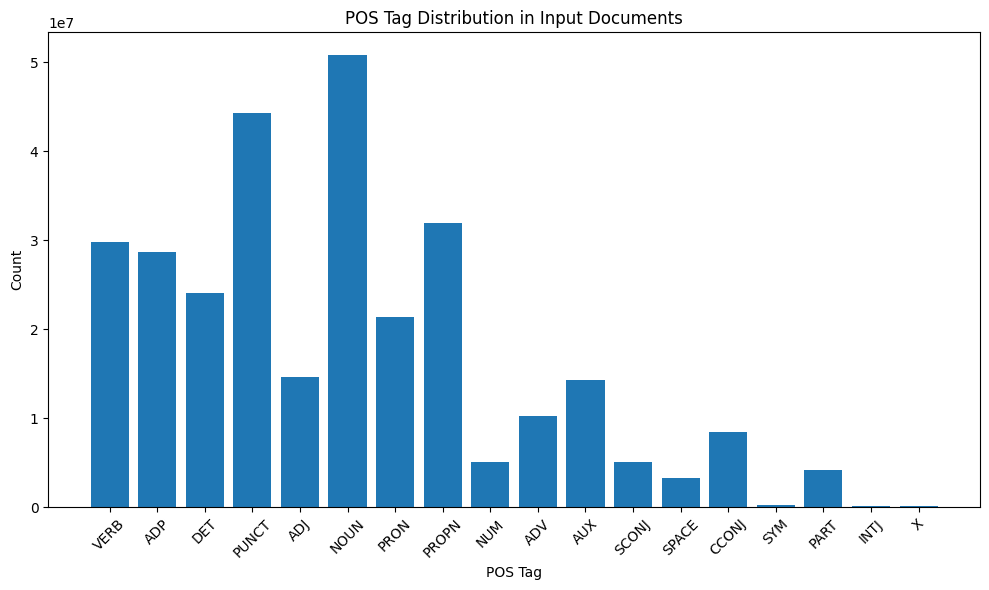

In [30]:
# Analyze the distribution of part-of-speech tags in the input documents
nlp = spacy.load("en_core_web_sm")

def iter_chunks(text: str, chunk_chars: int = 200_000):
    for i in range(0, len(text), chunk_chars):
        yield text[i:i + chunk_chars]

# To avoid memory issues with large documents, we will process the input documents in chunks.
def count_pos_from_split_docs(split_docs, chunk_size: int = 200_000, batch_size: int = 32) -> Counter:
    counts = Counter()

    chunk_stream = (
        chunk
        for doc in split_docs
        for doc_text in docs
        for chunk in iter_chunks(doc_text.strip(), chunk_size)
        if chunk
    )

    for doc in nlp.pipe(chunk_stream, batch_size=batch_size):
        for token in doc:
            counts[token.pos_] += 1

    return counts

pos_counts = count_pos_from_split_docs(split_docs)

print("Part-of-speech tag distribution in input documents:")
for pos_tag, count in pos_counts.items():
    print(f"{pos_tag}: {count}")

def plot_pos_distribution(pos_counts: dict[str, int], title: str) -> None:
    plt.figure(figsize=(10, 6))
    plt.bar(
        list(pos_counts.keys()),
        list(pos_counts.values())
    )
    plt.title(title)
    plt.xlabel("POS Tag")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_pos_distribution(pos_counts, "POS Tag Distribution in Input Documents")

## Model Definition

In [31]:
class MultiDocumentSummarizer:
    """
    MultiDocumentSummarizer is a class that defines a transformer-based model for
    multi-document summarization.
    """

    @staticmethod
    def _apply_stable_model_config(model: BartForConditionalGeneration) -> None:
        """Apply config values that must remain stable across all checkpoints."""
        if model.generation_config is None:
            model.generation_config = GenerationConfig.from_model_config(model.config)

        model.generation_config.forced_bos_token_id = FORCED_BOS_TOKEN_ID

    def __init__(self, model_name: str = MODEL_NAME):
        """Initializes the multi-document summarization model."""
        self.model_name = model_name
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=HF_CACHE)
        cfg = AutoConfig.from_pretrained(model_name, cache_dir=HF_CACHE)
        cfg.tie_word_embeddings = TIE_WORD_EMBEDDINGS
        self.model = AutoModelForSeq2SeqLM.from_pretrained(
            model_name,
            config=cfg,
            cache_dir=HF_CACHE
        ).to(device)
        self.model = cast(BartForConditionalGeneration, self.model)
        self._apply_stable_model_config(self.model)
        self.rouge_metric = evaluate.load("rouge")

    def _compute_metrics(self, eval_preds: EvalPrediction) -> dict[str, float]:
        """Computes ROUGE metrics for evaluation."""
        predictions = eval_preds.predictions
        label_ids = eval_preds.label_ids

        # Some versions return tuple(preds, ...) instead of just preds
        if isinstance(predictions, tuple):
            predictions = predictions[0]

        # If predictions are logits, we need to convert them to token ids
        if isinstance(predictions, np.ndarray) and predictions.ndim == 3:
            predictions = np.argmax(predictions, axis=-1)

        # Ensure integer ids are in valid range for decoding
        predictions = np.asarray(predictions, dtype=np.int64)
        labels = np.asarray(label_ids, dtype=np.int64)

        vocab_max = self.tokenizer.vocab_size - 1
        predictions = np.clip(predictions, 0, vocab_max)

        # Replace ignore index (-100) in predictions with pad_token_id for decoding
        labels = np.where(labels != -100, labels, self.tokenizer.pad_token_id)
        labels = np.clip(labels, 0, vocab_max)

        decoded_preds = self.tokenizer.batch_decode(
            predictions, skip_special_tokens=True
        )
        decoded_labels = self.tokenizer.batch_decode(labels, skip_special_tokens=True)

        # Compute ROUGE scores
        rouge_scores = self.rouge_metric.compute(
            predictions=[pred.strip() for pred in decoded_preds],
            references=[label.strip() for label in decoded_labels],
            use_stemmer=True,
        )

        if rouge_scores is None:
            return {}

        return {k: round(float(v), 4) for k, v in rouge_scores.items()}

    def train(
        self,
        train_dataset: torch.utils.data.Dataset,
        eval_dataset: torch.utils.data.Dataset,
        output_dir: str = MODEL_OUTPUT_DIR,
        learning_rate: float = 2e-5,
        train_batch_size: int = 1,
        eval_batch_size: int = 2,
        num_train_epochs: int = 3,
        weight_decay: float = 0.01,
        logging_steps: int = 500,
        eval_steps: int = 2000,
        save_steps: int = 2000,
        report_to: str = "none",
        fp16: bool = (device == "cuda"),  # enable only if using cuda for training
    ) -> Seq2SeqTrainer:
        data_collator = DataCollatorForSeq2Seq(
            self.tokenizer,
            model=self.model,
            pad_to_multiple_of=8 if fp16 else None,
        )

        args = Seq2SeqTrainingArguments(
            output_dir=output_dir,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=learning_rate,
            per_device_train_batch_size=train_batch_size,
            per_device_eval_batch_size=eval_batch_size,
            num_train_epochs=num_train_epochs,
            weight_decay=weight_decay,
            logging_steps=logging_steps,
            save_total_limit=3,
            predict_with_generate=True,
            load_best_model_at_end=True,
            metric_for_best_model="eval_rougeL",
            greater_is_better=True,
            fp16=fp16,
            report_to=report_to,
            # Accumulate gradients over 8 steps to effectively increase
            # batch size without running out of memory
            gradient_accumulation_steps=8,
        )

        # Disable caching for training to save memory
        self.model.config.use_cache = False

        trainer = Seq2SeqTrainer(
            model=self.model,
            args=args,
            train_dataset=train_dataset,
            eval_dataset=eval_dataset,
            data_collator=data_collator,
            compute_metrics=self._compute_metrics,
        )

        # resume if checkpoint exists in the output directory
        last_checkpoint = get_last_checkpoint(output_dir)
        if last_checkpoint is not None:
            print(f"Resuming training from checkpoint: {last_checkpoint}")
            trainer.train(resume_from_checkpoint=last_checkpoint)
        else:
            print("No checkpoint found. Starting training from scratch.")
            trainer.train()

        # re-enable caching after training
        self.model.config.use_cache = True

        return trainer

    def generate_summary(
        self,
        doc: str,
        max_new_tokens: int = 256,
        min_new_tokens: int = 30,
        num_beams: int = 4,
    ) -> str:
        """
        Generates a summary for the given input documents.

        Args:
            doc (str): The input document(s) to summarize. For multi-document summarization,
                multiple documents should be concatenated into a single string with a separator token (e.g., " <SEP> ").
            max_length (int): The maximum length of the generated summary. Defaults to 256.
            min_length (int): The minimum length of the generated summary. Defaults to 30.
            num_beams (int): The number of beams to use for beam search during generation. Defaults to 4.
        """
        encoding: BatchEncoding = self.tokenizer(
            doc,
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            return_tensors="pt",
        ).to(device)

        # Move input tensors to the same device as the model
        model_inputs: dict[str, torch.Tensor] = {k: v.to(device) for k, v in encoding.items()}

        input_ids = model_inputs["input_ids"]
        attention_mask = model_inputs["attention_mask"]

        self.model.eval()
        with torch.no_grad():
            summary_ids = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                min_new_tokens=min_new_tokens,
                num_beams=num_beams,
                early_stopping=True,
            )

            return self.tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    def batch_generate_summaries(
        self,
        docs: List[str],
        max_new_tokens: int = 256,
        min_new_tokens: int = 30,
        num_beams: int = 4,
    ) -> List[str]:
        """Generates summaries for a batch of input documents."""
        encoding: BatchEncoding = self.tokenizer(
            docs,
            max_length=MAX_INPUT_LENGTH,
            padding=True,
            truncation=True,
            return_tensors="pt",
        ).to(device)

        # Move input tensors to the same device as the model
        model_inputs: dict[str, torch.Tensor] = {k: v.to(device) for k, v in encoding.items()}

        input_ids = model_inputs["input_ids"]
        attention_mask = model_inputs["attention_mask"]

        self.model.eval()
        with torch.no_grad():
            summary_ids = self.model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                min_new_tokens=min_new_tokens,
                num_beams=num_beams,
                early_stopping=True,
            )

            return self.tokenizer.batch_decode(summary_ids, skip_special_tokens=True)

    def generate_multi_doc_summary(
        self,
        docs: List[str],
        doc_sep_token: str = " <SEP> ",
        max_new_tokens: int = 256,
        min_new_tokens: int = 30,
        num_beams: int = 4,
    ) -> str:
        """Generates a single summary for multiple input documents."""
        combined_doc = doc_sep_token.join(
            doc.strip()
            for doc in docs
            if doc
            and doc.strip()  # only include non-empty documents after stripping whitespace
        )

        return self.generate_summary(
            combined_doc,
            max_new_tokens=max_new_tokens,
            min_new_tokens=min_new_tokens,
            num_beams=num_beams,
        )

    def save(self, save_directory: str = MODEL_OUTPUT_DIR):
        """Saves the fine-tuned model and tokenizer to the specified output directory."""
        self.model.save_pretrained(save_directory)
        self.tokenizer.save_pretrained(save_directory)

    @classmethod
    def load(cls, model_directory: str = MODEL_OUTPUT_DIR):
        """Loads a fine-tuned model and tokenizer from the specified directory."""
        cfg = AutoConfig.from_pretrained(model_directory, cache_dir=HF_CACHE)
        cfg.tie_word_embeddings = TIE_WORD_EMBEDDINGS
        model = AutoModelForSeq2SeqLM.from_pretrained(
            model_directory, config=cfg, cache_dir=HF_CACHE
        ).to(device)
        cls._apply_stable_model_config(model)
        tokenizer = AutoTokenizer.from_pretrained(model_directory, cache_dir=HF_CACHE)

        summarizer = cls().__new__(cls)  # Create an uninitialized instance
        summarizer.model_name = model_directory
        summarizer.model = model
        summarizer.tokenizer = tokenizer
        summarizer.rouge_metric = evaluate.load("rouge")

        return summarizer

## Model Training

In [32]:
summarizer = MultiDocumentSummarizer()

if DEV_MODE:
    print(
        "DEV MODE: Training on a smaller subset of the dataset for faster iterations."
    )

    # In dev mode, we will train for only 1 epoch with a smaller batch size to
    # speed up the training process.
    trainer = summarizer.train(
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
        num_train_epochs=1,
        train_batch_size=1,
        eval_batch_size=1,
        logging_steps=10,
        eval_steps=20,
        save_steps=20,
    )
else:
    print("PRODUCTION MODE: Training on the full dataset for better performance.")

    trainer = summarizer.train(
        train_dataset=train_tokenized,
        eval_dataset=val_tokenized,
    )

    summarizer.save()  # Save the fine-tuned model after training
    trainer.save_state()

print("Training complete. Best model saved to:", trainer.state.best_model_checkpoint)
print("Best ROUGE-L score:", trainer.state.best_metric)

PRODUCTION MODE: Training on the full dataset for better performance.
No checkpoint found. Starting training from scratch.


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.614800,2.535827,0.413300,0.151500,0.223300,0.223200
2,2.334000,2.504883,0.418700,0.156400,0.227000,0.226900


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1581: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 142, 'min_length': 56, 'early_stopping': True, 'num_beams': 4, 'length_penalty': 2.0, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decode

Training complete. Best model saved to: /content/drive/MyDrive/rai8001/models/multi_doc_summarizer/checkpoint-16863
Best ROUGE-L score: 0.227


## Model Evaluation

### Sample Generation

In [33]:
print("Single document summary generation example:")
print("Generated summary:", summarizer.generate_summary(train_raw[0]["document"]))
print("\n")
print("Reference summary:", train_raw[0]["summary"])


print("\n")
print("Multi-document summary generation example:")

# Each document is a concatenation of multiple news articles, separated by
# "|||||" in the original dataset. We will split them into individual documents
# and then generate a summary for the combined input.
sample_docs = train_raw[0]["document"].split("|||||")
for i, doc in enumerate(sample_docs):
    print(f"Document {i + 1}:", doc[:500], "...\n")

sample_multi_doc_summary = summarizer.generate_multi_doc_summary(sample_docs)

print("\n")
print("Generated summary:", sample_multi_doc_summary)
print("\n")
print("Reference summary:", train_raw[0]["summary"])

Single document summary generation example:
Generated summary: – The unemployment rate fell to 8.2% last month, but it was mostly because fewer Americans were looking for work. The Labor Department says the economy added 120,000 jobs in March, down from more than 200,000 in each of the previous three months. The rate dropped because fewer people searched for work, the Wall Street Journal reports. The economy has added 858,000 new jobs since December—the best four months of hiring in two years. But Federal Reserve Chairman Ben Bernanke has cautioned that the current hiring pace is unlikely to continue without more consumer spending.


Reference summary: – The unemployment rate dropped to 8.2% last month, but the economy only added 120,000 jobs, when 203,000 new jobs had been predicted, according to today's jobs report. Reaction on the Wall Street Journal's MarketBeat Blog was swift: "Woah!!! Bad number." The unemployment rate, however, is better news; it had been expected to hold steady

### Evaluation on Test Set

In [34]:
test_results = trainer.predict(test_tokenized, metric_key_prefix="test")

print("Test set evaluation results:")

if test_results.metrics is None:
    print("No metrics were computed during evaluation.")
else:
    for metric_name, metric_value in test_results.metrics.items():
        print(f"{metric_name}: {metric_value:.4f}")

Test set evaluation results:
test_loss: 2.4919
test_rouge1: 0.4210
test_rouge2: 0.1575
test_rougeL: 0.2280
test_rougeLsum: 0.2281
test_runtime: 7120.0595
test_samples_per_second: 0.7900
test_steps_per_second: 0.3950
